Inspect dataset structure, visualize class
distribution, identify imbalance issues, and
suggest handling strategies.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

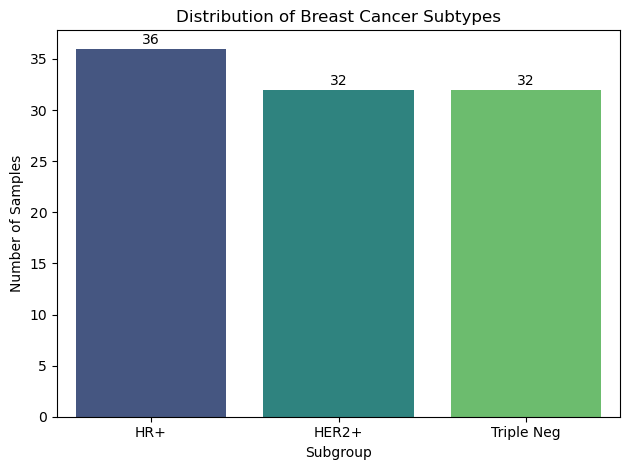

In [32]:
clinical_df = pd.read_csv('Train_clinical.tsv', sep='\t')
subgroup_counts = clinical_df['Subgroup'].value_counts()

sns.barplot(x=subgroup_counts.index, y=subgroup_counts.values, palette='viridis')
plt.title('Distribution of Breast Cancer Subtypes')
plt.xlabel('Subgroup')
plt.ylabel('Number of Samples')

for i, count in enumerate(subgroup_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center')

plt.tight_layout()

This plot shows a class balance of 36 / 32 / 32, which is mildly imbalanced but not severely. 

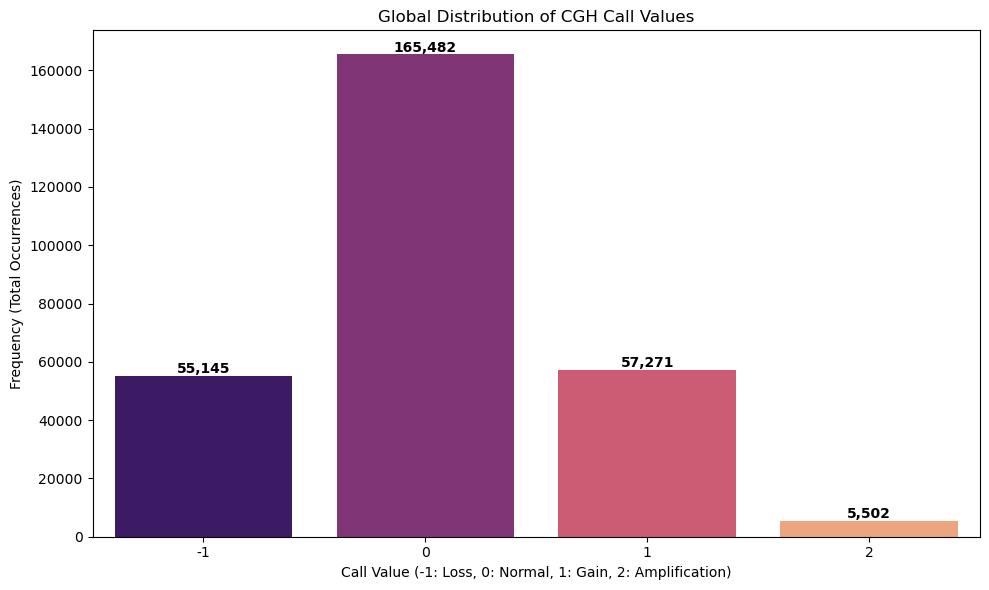

In [ ]:

call_df = pd.read_csv('Train_call.tsv', sep='\t')
data_columns = call_df.drop(columns=['Chromosome', 'Start', 'End', 'Nclone'])
calls_melted = data_columns.melt(var_name='Sample', value_name='Call_Value')
call_counts = calls_melted['Call_Value'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=call_counts.index, y=call_counts.values, palette='magma')
plt.title('Global Distribution of CGH Call Values')
plt.xlabel('Call Value (-1: Loss, 0: Normal, 1: Gain, 2: Amplification)')
plt.ylabel('Frequency (Total Occurrences)')

for i, count in enumerate(call_counts.values):
    plt.text(i, count + 1000, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [35]:
# # transpose the matrix to get samples as rows and features as columns
call_df = pd.read_csv('Train_call.tsv', sep='\t')

regions = call_df['Chromosome'].astype(str) + '_' + \
          call_df['Start'].astype(str) + '_' + \
          call_df['End'].astype(str)

call_data_only = call_df.drop(columns=['Chromosome', 'Start', 'End', 'Nclone'])
call_data_only.index = regions
call_transposed = call_data_only.T
call_transposed.index.name = 'Sample'
call_transposed.reset_index(inplace=True)
final_training_df = call_transposed.merge(clinical_df, on='Sample')
final_training_df.to_csv('Processed_Train_Data.csv', index=False)